In [137]:
import numpy as np
import pandas as pd

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [141]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [142]:
import joblib

In [143]:
import warnings
warnings.filterwarnings('ignore')

In [144]:
# Upload the Required Dataset
flight_data = pd.read_csv('flight_delay.csv')
flight_data

,is_delay,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime
0,1.0,2014,1,1,1,3,2014-01-01,UA,LAX,CA,ORD,IL,900,0.0,0.0,1744.0,7,43.0,43.0,218.0
1,0.0,2014,1,1,1,3,2014-01-01,AA,IAH,TX,DFW,TX,1750,0.0,0.0,224.0,1,2.0,2.0,50.0
2,1.0,2014,1,1,1,3,2014-01-01,AA,LAX,CA,ORD,IL,1240,0.0,0.0,1744.0,7,26.0,26.0,220.0
3,1.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,1905,0.0,0.0,1235.0,5,159.0,159.0,169.0
4,0.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,CLT,NC,1115,0.0,0.0,936.0,4,-13.0,0.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,1.0,2018,4,12,31,1,2018-12-31,AA,DFW,TX,DEN,CO,1440,0.0,0.0,641.0,3,24.0,24.0,100.0
1635586,0.0,2018,4,12,31,1,2018-12-31,DL,PHX,AZ,ATL,GA,1420,0.0,0.0,1587.0,7,-14.0,0.0,179.0
1635587,1.0,2018,4,12,31,1,2018-12-31,AA,ORD,IL,SFO,CA,1700,0.0,0.0,1846.0,8,39.0,39.0,272.0
1635588,0.0,2018,4,12,31,1,2018-12-31,AA,ORD,IL,LAX,CA,720,0.0,0.0,1744.0,7,-10.0,0.0,240.0


In [145]:
# First Rows
flight_data.head(10)

,is_delay,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime
0,1.0,2014,1,1,1,3,2014-01-01,UA,LAX,CA,ORD,IL,900,0.0,0.0,1744.0,7,43.0,43.0,218.0
1,0.0,2014,1,1,1,3,2014-01-01,AA,IAH,TX,DFW,TX,1750,0.0,0.0,224.0,1,2.0,2.0,50.0
2,1.0,2014,1,1,1,3,2014-01-01,AA,LAX,CA,ORD,IL,1240,0.0,0.0,1744.0,7,26.0,26.0,220.0
3,1.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,1905,0.0,0.0,1235.0,5,159.0,159.0,169.0
4,0.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,CLT,NC,1115,0.0,0.0,936.0,4,-13.0,0.0,108.0
5,0.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,SFO,CA,1605,0.0,0.0,1464.0,6,4.0,4.0,208.0
6,1.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,DEN,CO,1145,0.0,0.0,641.0,3,24.0,24.0,96.0
7,1.0,2014,1,1,1,3,2014-01-01,AA,DEN,CO,DFW,TX,1330,0.0,0.0,641.0,3,26.0,26.0,77.0
8,1.0,2014,1,1,1,3,2014-01-01,AA,PHX,AZ,DFW,TX,1545,0.0,0.0,868.0,4,122.0,122.0,110.0
9,1.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,2030,0.0,0.0,1235.0,5,16.0,16.0,168.0


In [146]:
# Last Rows
flight_data.tail(10)

,is_delay,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime
1635580,0.0,2018,4,12,31,1,2018-12-31,DL,ATL,GA,ORD,IL,1651,0.0,0.0,606.0,3,-11.0,0.0,96.0
1635581,0.0,2018,4,12,31,1,2018-12-31,DL,ATL,GA,ORD,IL,2232,0.0,0.0,606.0,3,-28.0,0.0,82.0
1635582,1.0,2018,4,12,31,1,2018-12-31,AA,LAX,CA,CLT,NC,2249,0.0,0.0,2125.0,9,43.0,43.0,226.0
1635583,0.0,2018,4,12,31,1,2018-12-31,DL,ATL,GA,DFW,TX,1621,0.0,0.0,731.0,3,5.0,5.0,118.0
1635584,0.0,2018,4,12,31,1,2018-12-31,DL,ATL,GA,SFO,CA,1945,0.0,0.0,2139.0,9,-2.0,0.0,289.0
1635585,1.0,2018,4,12,31,1,2018-12-31,AA,DFW,TX,DEN,CO,1440,0.0,0.0,641.0,3,24.0,24.0,100.0
1635586,0.0,2018,4,12,31,1,2018-12-31,DL,PHX,AZ,ATL,GA,1420,0.0,0.0,1587.0,7,-14.0,0.0,179.0
1635587,1.0,2018,4,12,31,1,2018-12-31,AA,ORD,IL,SFO,CA,1700,0.0,0.0,1846.0,8,39.0,39.0,272.0
1635588,0.0,2018,4,12,31,1,2018-12-31,AA,ORD,IL,LAX,CA,720,0.0,0.0,1744.0,7,-10.0,0.0,240.0
1635589,1.0,2018,4,12,31,1,2018-12-31,AA,DFW,TX,DEN,CO,1245,0.0,0.0,641.0,3,19.0,19.0,93.0


In [147]:
# Length of a Dataset
len(flight_data)

1635590

In [148]:
# Datatypes of Each Column
flight_data.dtypes

is_delay             float64
Year                   int64
Quarter                int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
FlightDate            object
Reporting_Airline     object
Origin                object
OriginState           object
Dest                  object
DestState             object
CRSDepTime             int64
Cancelled            float64
Diverted             float64
Distance             float64
DistanceGroup          int64
ArrDelay             float64
ArrDelayMinutes      float64
AirTime              float64
dtype: object

In [149]:
# Size of a Dataset
flight_data.size

32711800

In [150]:
# Columns of a Dataset
flight_data.columns

Index(['is_delay', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'FlightDate', 'Reporting_Airline', 'Origin', 'OriginState', 'Dest',
       'DestState', 'CRSDepTime', 'Cancelled', 'Diverted', 'Distance',
       'DistanceGroup', 'ArrDelay', 'ArrDelayMinutes', 'AirTime'],
      dtype='object')

In [151]:
# Put 'is_delay' at last
cols = list(flight_data.columns)
cols

['is_delay',
 'Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'Cancelled',
 'Diverted',
 'Distance',
 'DistanceGroup',
 'ArrDelay',
 'ArrDelayMinutes',
 'AirTime']

In [152]:
cols.remove('is_delay') 
cols.append('is_delay')

In [153]:
cols

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'Cancelled',
 'Diverted',
 'Distance',
 'DistanceGroup',
 'ArrDelay',
 'ArrDelayMinutes',
 'AirTime',
 'is_delay']

In [154]:
flight_data = flight_data[cols]
flight_data

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,is_delay
0,2014,1,1,1,3,2014-01-01,UA,LAX,CA,ORD,IL,900,0.0,0.0,1744.0,7,43.0,43.0,218.0,1.0
1,2014,1,1,1,3,2014-01-01,AA,IAH,TX,DFW,TX,1750,0.0,0.0,224.0,1,2.0,2.0,50.0,0.0
2,2014,1,1,1,3,2014-01-01,AA,LAX,CA,ORD,IL,1240,0.0,0.0,1744.0,7,26.0,26.0,220.0,1.0
3,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,1905,0.0,0.0,1235.0,5,159.0,159.0,169.0,1.0
4,2014,1,1,1,3,2014-01-01,AA,DFW,TX,CLT,NC,1115,0.0,0.0,936.0,4,-13.0,0.0,108.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,4,12,31,1,2018-12-31,AA,DFW,TX,DEN,CO,1440,0.0,0.0,641.0,3,24.0,24.0,100.0,1.0
1635586,2018,4,12,31,1,2018-12-31,DL,PHX,AZ,ATL,GA,1420,0.0,0.0,1587.0,7,-14.0,0.0,179.0,0.0
1635587,2018,4,12,31,1,2018-12-31,AA,ORD,IL,SFO,CA,1700,0.0,0.0,1846.0,8,39.0,39.0,272.0,1.0
1635588,2018,4,12,31,1,2018-12-31,AA,ORD,IL,LAX,CA,720,0.0,0.0,1744.0,7,-10.0,0.0,240.0,0.0


In [155]:
# Value Counts
flight_data['is_delay'].value_counts()

is_delay
0.0    1292258
1.0     343332
Name: count, dtype: int64

In [156]:
# Mapping
flight_data['is_delay'] = flight_data['is_delay'].replace(
    {
        0.0 : 'No',
        1.0 : 'Yes'
    }
)
flight_data['is_delay']

0          Yes
1           No
2          Yes
3          Yes
4           No
          ... 
1635585    Yes
1635586     No
1635587    Yes
1635588     No
1635589    Yes
Name: is_delay, Length: 1635590, dtype: object

In [157]:
flight_data

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,is_delay
0,2014,1,1,1,3,2014-01-01,UA,LAX,CA,ORD,IL,900,0.0,0.0,1744.0,7,43.0,43.0,218.0,Yes
1,2014,1,1,1,3,2014-01-01,AA,IAH,TX,DFW,TX,1750,0.0,0.0,224.0,1,2.0,2.0,50.0,No
2,2014,1,1,1,3,2014-01-01,AA,LAX,CA,ORD,IL,1240,0.0,0.0,1744.0,7,26.0,26.0,220.0,Yes
3,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,1905,0.0,0.0,1235.0,5,159.0,159.0,169.0,Yes
4,2014,1,1,1,3,2014-01-01,AA,DFW,TX,CLT,NC,1115,0.0,0.0,936.0,4,-13.0,0.0,108.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,4,12,31,1,2018-12-31,AA,DFW,TX,DEN,CO,1440,0.0,0.0,641.0,3,24.0,24.0,100.0,Yes
1635586,2018,4,12,31,1,2018-12-31,DL,PHX,AZ,ATL,GA,1420,0.0,0.0,1587.0,7,-14.0,0.0,179.0,No
1635587,2018,4,12,31,1,2018-12-31,AA,ORD,IL,SFO,CA,1700,0.0,0.0,1846.0,8,39.0,39.0,272.0,Yes
1635588,2018,4,12,31,1,2018-12-31,AA,ORD,IL,LAX,CA,720,0.0,0.0,1744.0,7,-10.0,0.0,240.0,No


In [158]:
# Value Counts in every column
flight_data['Quarter'].value_counts()

Quarter
3    430851
4    418865
2    406644
1    379230
Name: count, dtype: int64

In [159]:
flight_data['Quarter'] = flight_data['Quarter'].replace(
    {
        1 : 'Quarter 1',
        2 : 'Quarter 2',
        3 : 'Quarter 3',
        4 : 'Quarter 4'
    }
)
flight_data['Quarter']

0          Quarter 1
1          Quarter 1
2          Quarter 1
3          Quarter 1
4          Quarter 1
             ...    
1635585    Quarter 4
1635586    Quarter 4
1635587    Quarter 4
1635588    Quarter 4
1635589    Quarter 4
Name: Quarter, Length: 1635590, dtype: object

In [160]:
flight_data['Quarter'].value_counts()

Quarter
Quarter 3    430851
Quarter 4    418865
Quarter 2    406644
Quarter 1    379230
Name: count, dtype: int64

In [161]:
flight_data['Month'].value_counts()

Month
7     147396
8     146923
10    144140
12    138166
5     137769
6     137470
11    136559
9     136532
3     135739
4     131405
1     127059
2     116432
Name: count, dtype: int64

In [162]:
flight_data['Month'] = flight_data['Month'].replace(
    {
        1 : 'January',
        2 : 'February',
        3 : 'March',
        4 : 'April',
        5 : 'May',
        6 : 'June',
        7 : 'July',
        8 : 'August',
        9 : 'September',
        10 : 'October',
        11 : 'November',
        12 : 'December'
    }
)
flight_data['Month']

0           January
1           January
2           January
3           January
4           January
             ...   
1635585    December
1635586    December
1635587    December
1635588    December
1635589    December
Name: Month, Length: 1635590, dtype: object

In [163]:
flight_data['Month'].value_counts()

Month
July         147396
August       146923
October      144140
December     138166
May          137769
June         137470
November     136559
September    136532
March        135739
April        131405
January      127059
February     116432
Name: count, dtype: int64

In [164]:
flight_data['DayOfWeek'].value_counts()

DayOfWeek
5    244421
4    243412
1    243115
3    240248
2    236353
7    229923
6    198118
Name: count, dtype: int64

In [165]:
flight_data['DayOfWeek'] = flight_data['DayOfWeek'].replace({
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
})
flight_data['DayOfWeek'] 

0          Wednesday
1          Wednesday
2          Wednesday
3          Wednesday
4          Wednesday
             ...    
1635585       Monday
1635586       Monday
1635587       Monday
1635588       Monday
1635589       Monday
Name: DayOfWeek, Length: 1635590, dtype: object

In [166]:
flight_data['DayOfWeek'].value_counts()

DayOfWeek
Friday       244421
Thursday     243412
Monday       243115
Wednesday    240248
Tuesday      236353
Sunday       229923
Saturday     198118
Name: count, dtype: int64

In [167]:
flight_data['DayofMonth'].value_counts()

DayofMonth
19    54561
20    54497
16    54381
26    54320
18    54275
13    54157
12    54154
21    54151
17    54025
15    53975
11    53936
9     53908
10    53896
14    53874
22    53822
2     53778
7     53649
27    53613
5     53580
6     53569
8     53552
23    53480
28    53409
25    53349
1     53008
3     52938
24    52591
4     52502
29    50691
30    49772
31    30177
Name: count, dtype: int64

In [168]:
flight_data['Reporting_Airline'].value_counts()

Reporting_Airline
AA    593362
UA    492842
DL    270148
WN    181439
OO     97799
Name: count, dtype: int64

In [169]:
flight_data['Reporting_Airline'] = flight_data['Reporting_Airline'].replace(
    {
        'AA' : 'American Airlines',
        'UA' : 'United Airlines',
        'DL' : 'Delta Airlines',
        'WN' : 'Southwest Airlines',
        'OO' : 'SkyWest Airlines'
    }
)
flight_data['Reporting_Airline']

0            United Airlines
1          American Airlines
2          American Airlines
3          American Airlines
4          American Airlines
                 ...        
1635585    American Airlines
1635586       Delta Airlines
1635587    American Airlines
1635588    American Airlines
1635589    American Airlines
Name: Reporting_Airline, Length: 1635590, dtype: object

In [170]:
flight_data['Reporting_Airline'].value_counts()

Reporting_Airline
American Airlines     593362
United Airlines       492842
Delta Airlines        270148
Southwest Airlines    181439
SkyWest Airlines       97799
Name: count, dtype: int64

In [171]:
flight_data['Origin'].value_counts()

Origin
LAX    243778
ORD    213952
DFW    202683
SFO    201765
ATL    189967
DEN    186918
PHX    162353
IAH    132177
CLT    101997
Name: count, dtype: int64

In [172]:
flight_data['Origin'] = flight_data['Origin'].replace({
    'LAX': 'Los Angeles International Airport',
    'ORD': 'Chicago O’Hare International Airport',
    'DFW': 'Dallas/Fort Worth International Airport',
    'SFO': 'San Francisco International Airport',
    'ATL': 'Atlanta Hartsfield–Jackson International Airport',
    'DEN': 'Denver International Airport',
    'PHX': 'Phoenix Sky Harbor International Airport',
    'IAH': 'Houston George Bush Intercontinental Airport',
    'CLT': 'Charlotte Douglas International Airport'
})
flight_data['Origin']

0                     Los Angeles International Airport
1          Houston George Bush Intercontinental Airport
2                     Los Angeles International Airport
3               Dallas/Fort Worth International Airport
4               Dallas/Fort Worth International Airport
                               ...                     
1635585         Dallas/Fort Worth International Airport
1635586        Phoenix Sky Harbor International Airport
1635587            Chicago O’Hare International Airport
1635588            Chicago O’Hare International Airport
1635589         Dallas/Fort Worth International Airport
Name: Origin, Length: 1635590, dtype: object

In [173]:
flight_data['OriginState'].value_counts()

OriginState
CA    445543
TX    334860
IL    213952
GA    189967
CO    186918
AZ    162353
NC    101997
Name: count, dtype: int64

In [174]:
flight_data['OriginState'] = flight_data['OriginState'].replace(
    {
        'CA' : 'California',
        'TX' : 'Texas',
        'IL' : 'Illinois',
        'GA' : 'Geogia',
        'CO' : 'Colorado',
        'AZ' : 'Arizona',
        'NC' : 'North Carolina'
    }
)
flight_data['OriginState']

0          California
1               Texas
2          California
3               Texas
4               Texas
              ...    
1635585         Texas
1635586       Arizona
1635587      Illinois
1635588      Illinois
1635589         Texas
Name: OriginState, Length: 1635590, dtype: object

In [175]:
flight_data['OriginState'].value_counts()

OriginState
California        445543
Texas             334860
Illinois          213952
Geogia            189967
Colorado          186918
Arizona           162353
North Carolina    101997
Name: count, dtype: int64

In [176]:
flight_data['Dest'].value_counts()

Dest
LAX    244848
ORD    216022
SFO    201693
DFW    201431
ATL    190907
DEN    184615
PHX    162280
IAH    131646
CLT    102148
Name: count, dtype: int64

In [177]:
flight_data['Dest'] = flight_data['Dest'].replace({
    'LAX': 'Los Angeles International Airport',
    'ORD': 'Chicago O’Hare International Airport',
    'SFO': 'San Francisco International Airport',
    'DFW': 'Dallas/Fort Worth International Airport',
    'ATL': 'Atlanta Hartsfield–Jackson International Airport',
    'DEN': 'Denver International Airport',
    'PHX': 'Phoenix Sky Harbor International Airport',
    'IAH': 'Houston George Bush Intercontinental Airport',
    'CLT': 'Charlotte Douglas International Airport'
})
flight_data['Dest'] 

0                      Chicago O’Hare International Airport
1                   Dallas/Fort Worth International Airport
2                      Chicago O’Hare International Airport
3                         Los Angeles International Airport
4                   Charlotte Douglas International Airport
                                 ...                       
1635585                        Denver International Airport
1635586    Atlanta Hartsfield–Jackson International Airport
1635587                 San Francisco International Airport
1635588                   Los Angeles International Airport
1635589                        Denver International Airport
Name: Dest, Length: 1635590, dtype: object

In [178]:
flight_data['Dest'].value_counts()

Dest
Los Angeles International Airport                   244848
Chicago O’Hare International Airport                216022
San Francisco International Airport                 201693
Dallas/Fort Worth International Airport             201431
Atlanta Hartsfield–Jackson International Airport    190907
Denver International Airport                        184615
Phoenix Sky Harbor International Airport            162280
Houston George Bush Intercontinental Airport        131646
Charlotte Douglas International Airport             102148
Name: count, dtype: int64

In [179]:
flight_data['DestState'].value_counts()

DestState
CA    446541
TX    333077
IL    216022
GA    190907
CO    184615
AZ    162280
NC    102148
Name: count, dtype: int64

In [180]:
flight_data['DestState'] = flight_data['DestState'].replace({
    'CA': 'California',
    'TX': 'Texas',
    'IL': 'Illinois',
    'GA': 'Georgia',
    'CO': 'Colorado',
    'AZ': 'Arizona',
    'NC': 'North Carolina'
})
flight_data['DestState']

0                Illinois
1                   Texas
2                Illinois
3              California
4          North Carolina
                ...      
1635585          Colorado
1635586           Georgia
1635587        California
1635588        California
1635589          Colorado
Name: DestState, Length: 1635590, dtype: object

In [181]:
flight_data['DestState'].value_counts()

DestState
California        446541
Texas             333077
Illinois          216022
Georgia           190907
Colorado          184615
Arizona           162280
North Carolina    102148
Name: count, dtype: int64

In [182]:
flight_data['Cancelled'].value_counts()

Cancelled
0.0    1635590
Name: count, dtype: int64

In [183]:
flight_data['Diverted'].value_counts()

Diverted
0.0    1635590
Name: count, dtype: int64

In [184]:
flight_data['Cancelled'] = flight_data['Cancelled'].replace(
    {
        0.0 : 'Not Cancelled'
    }
)
flight_data['Cancelled']

0          Not Cancelled
1          Not Cancelled
2          Not Cancelled
3          Not Cancelled
4          Not Cancelled
               ...      
1635585    Not Cancelled
1635586    Not Cancelled
1635587    Not Cancelled
1635588    Not Cancelled
1635589    Not Cancelled
Name: Cancelled, Length: 1635590, dtype: object

In [185]:
flight_data['Diverted'] = flight_data['Diverted'].replace(
    {
        0.0 : 'Not Diverted'
    }
)
flight_data['Diverted']

0          Not Diverted
1          Not Diverted
2          Not Diverted
3          Not Diverted
4          Not Diverted
               ...     
1635585    Not Diverted
1635586    Not Diverted
1635587    Not Diverted
1635588    Not Diverted
1635589    Not Diverted
Name: Diverted, Length: 1635590, dtype: object

In [186]:
flight_data['DistanceGroup'].value_counts()

DistanceGroup
4     397266
3     341728
2     183001
8     145250
6     145178
7     137826
5     131283
1      93468
9      47157
10     13433
Name: count, dtype: int64

In [187]:
flight_data['DistanceGroup'] = flight_data['DistanceGroup'].replace({
    1: '1–250 miles',
    2: '251–500 miles',
    3: '501–750 miles',
    4: '751–1000 miles',
    5: '1001–1250 miles',
    6: '1251–1500 miles',
    7: '1501–2000 miles',
    8: '2001–2500 miles',
    9: '2501–3000 miles',
    10: '3001+ miles'
})
flight_data['DistanceGroup']

0          1501–2000 miles
1              1–250 miles
2          1501–2000 miles
3          1001–1250 miles
4           751–1000 miles
                ...       
1635585      501–750 miles
1635586    1501–2000 miles
1635587    2001–2500 miles
1635588    1501–2000 miles
1635589      501–750 miles
Name: DistanceGroup, Length: 1635590, dtype: object

In [188]:
flight_data['CRSDepTime'] = flight_data['CRSDepTime'].astype(str).str.zfill(4)
flight_data['CRSDepTime']

0          0900
1          1750
2          1240
3          1905
4          1115
           ... 
1635585    1440
1635586    1420
1635587    1700
1635588    0720
1635589    1245
Name: CRSDepTime, Length: 1635590, dtype: object

In [189]:
flight_data['CRSDepTime'] = flight_data['CRSDepTime'].str[:2] + ':' + flight_data['CRSDepTime'].str[2:]
flight_data['CRSDepTime']

0          09:00
1          17:50
2          12:40
3          19:05
4          11:15
           ...  
1635585    14:40
1635586    14:20
1635587    17:00
1635588    07:20
1635589    12:45
Name: CRSDepTime, Length: 1635590, dtype: object

In [190]:
def time_of_day(dep_time):
    hour = int(dep_time.split(':')[0])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

In [191]:
flight_data['DepPeriod'] = flight_data['CRSDepTime'].apply(time_of_day)
flight_data['DepPeriod']

0            Morning
1            Evening
2          Afternoon
3            Evening
4            Morning
             ...    
1635585    Afternoon
1635586    Afternoon
1635587      Evening
1635588      Morning
1635589    Afternoon
Name: DepPeriod, Length: 1635590, dtype: object

In [192]:
flight_data['DepPeriod'].value_counts()

DepPeriod
Morning      668134
Afternoon    501974
Evening      335570
Night        129912
Name: count, dtype: int64

In [193]:
flight_data

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,...,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,is_delay,DepPeriod
0,2014,Quarter 1,January,1,Wednesday,2014-01-01,United Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,09:00,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,43.0,43.0,218.0,Yes,Morning
1,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Houston George Bush Intercontinental Airport,Texas,Dallas/Fort Worth International Airport,...,17:50,Not Cancelled,Not Diverted,224.0,1–250 miles,2.0,2.0,50.0,No,Evening
2,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,12:40,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,26.0,26.0,220.0,Yes,Afternoon
3,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Los Angeles International Airport,...,19:05,Not Cancelled,Not Diverted,1235.0,1001–1250 miles,159.0,159.0,169.0,Yes,Evening
4,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Charlotte Douglas International Airport,...,11:15,Not Cancelled,Not Diverted,936.0,751–1000 miles,-13.0,0.0,108.0,No,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Dallas/Fort Worth International Airport,Texas,Denver International Airport,...,14:40,Not Cancelled,Not Diverted,641.0,501–750 miles,24.0,24.0,100.0,Yes,Afternoon
1635586,2018,Quarter 4,December,31,Monday,2018-12-31,Delta Airlines,Phoenix Sky Harbor International Airport,Arizona,Atlanta Hartsfield–Jackson International Airport,...,14:20,Not Cancelled,Not Diverted,1587.0,1501–2000 miles,-14.0,0.0,179.0,No,Afternoon
1635587,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,San Francisco International Airport,...,17:00,Not Cancelled,Not Diverted,1846.0,2001–2500 miles,39.0,39.0,272.0,Yes,Evening
1635588,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,Los Angeles International Airport,...,07:20,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,-10.0,0.0,240.0,No,Morning


In [194]:
flight_data['Year'].value_counts()

Year
2016    357279
2017    344450
2018    338533
2015    319396
2014    275932
Name: count, dtype: int64

In [195]:
flight_data['Year'] = flight_data['Year'].astype('str')
flight_data['Year']

0          2014
1          2014
2          2014
3          2014
4          2014
           ... 
1635585    2018
1635586    2018
1635587    2018
1635588    2018
1635589    2018
Name: Year, Length: 1635590, dtype: object

In [196]:
flight_data['DayofMonth'] = flight_data['DayofMonth'].astype('str')
flight_data['DayofMonth']

0           1
1           1
2           1
3           1
4           1
           ..
1635585    31
1635586    31
1635587    31
1635588    31
1635589    31
Name: DayofMonth, Length: 1635590, dtype: object

In [197]:
flight_data.dtypes

Year                  object
Quarter               object
Month                 object
DayofMonth            object
DayOfWeek             object
FlightDate            object
Reporting_Airline     object
Origin                object
OriginState           object
Dest                  object
DestState             object
CRSDepTime            object
Cancelled             object
Diverted              object
Distance             float64
DistanceGroup         object
ArrDelay             float64
ArrDelayMinutes      float64
AirTime              float64
is_delay              object
DepPeriod             object
dtype: object

In [198]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635590 entries, 0 to 1635589
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Year               1635590 non-null  object 
 1   Quarter            1635590 non-null  object 
 2   Month              1635590 non-null  object 
 3   DayofMonth         1635590 non-null  object 
 4   DayOfWeek          1635590 non-null  object 
 5   FlightDate         1635590 non-null  object 
 6   Reporting_Airline  1635590 non-null  object 
 7   Origin             1635590 non-null  object 
 8   OriginState        1635590 non-null  object 
 9   Dest               1635590 non-null  object 
 10  DestState          1635590 non-null  object 
 11  CRSDepTime         1635590 non-null  object 
 12  Cancelled          1635590 non-null  object 
 13  Diverted           1635590 non-null  object 
 14  Distance           1635590 non-null  float64
 15  DistanceGroup      1635590 non-n

In [199]:
flight_data.isnull()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,...,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,is_delay,DepPeriod
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1635586,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1635587,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1635588,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [200]:
flight_data.isnull().sum()

Year                 0
Quarter              0
Month                0
DayofMonth           0
DayOfWeek            0
FlightDate           0
Reporting_Airline    0
Origin               0
OriginState          0
Dest                 0
DestState            0
CRSDepTime           0
Cancelled            0
Diverted             0
Distance             0
DistanceGroup        0
ArrDelay             0
ArrDelayMinutes      0
AirTime              0
is_delay             0
DepPeriod            0
dtype: int64

In [201]:
flight_data.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Origin', 'OriginState', 'Dest', 'DestState',
       'CRSDepTime', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
       'ArrDelay', 'ArrDelayMinutes', 'AirTime', 'is_delay', 'DepPeriod'],
      dtype='object')

In [202]:
cols1 = list(flight_data.columns)
cols1

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'Cancelled',
 'Diverted',
 'Distance',
 'DistanceGroup',
 'ArrDelay',
 'ArrDelayMinutes',
 'AirTime',
 'is_delay',
 'DepPeriod']

In [203]:
cols1.remove('is_delay') 
cols1.remove('DepPeriod')

In [204]:
cols1.append('DepPeriod') 
cols1.append('is_delay')

In [205]:
cols1

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'Cancelled',
 'Diverted',
 'Distance',
 'DistanceGroup',
 'ArrDelay',
 'ArrDelayMinutes',
 'AirTime',
 'DepPeriod',
 'is_delay']

In [206]:
flight_data = flight_data[cols1]
flight_data

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,...,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,DepPeriod,is_delay
0,2014,Quarter 1,January,1,Wednesday,2014-01-01,United Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,09:00,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,43.0,43.0,218.0,Morning,Yes
1,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Houston George Bush Intercontinental Airport,Texas,Dallas/Fort Worth International Airport,...,17:50,Not Cancelled,Not Diverted,224.0,1–250 miles,2.0,2.0,50.0,Evening,No
2,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,12:40,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,26.0,26.0,220.0,Afternoon,Yes
3,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Los Angeles International Airport,...,19:05,Not Cancelled,Not Diverted,1235.0,1001–1250 miles,159.0,159.0,169.0,Evening,Yes
4,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Charlotte Douglas International Airport,...,11:15,Not Cancelled,Not Diverted,936.0,751–1000 miles,-13.0,0.0,108.0,Morning,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Dallas/Fort Worth International Airport,Texas,Denver International Airport,...,14:40,Not Cancelled,Not Diverted,641.0,501–750 miles,24.0,24.0,100.0,Afternoon,Yes
1635586,2018,Quarter 4,December,31,Monday,2018-12-31,Delta Airlines,Phoenix Sky Harbor International Airport,Arizona,Atlanta Hartsfield–Jackson International Airport,...,14:20,Not Cancelled,Not Diverted,1587.0,1501–2000 miles,-14.0,0.0,179.0,Afternoon,No
1635587,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,San Francisco International Airport,...,17:00,Not Cancelled,Not Diverted,1846.0,2001–2500 miles,39.0,39.0,272.0,Evening,Yes
1635588,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,Los Angeles International Airport,...,07:20,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,-10.0,0.0,240.0,Morning,No


In [207]:
flight_data.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Origin', 'OriginState', 'Dest', 'DestState',
       'CRSDepTime', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
       'ArrDelay', 'ArrDelayMinutes', 'AirTime', 'DepPeriod', 'is_delay'],
      dtype='object')

In [208]:
flight_data.describe()

,Distance,ArrDelay,ArrDelayMinutes,AirTime
count,1.635590e+06,1.635590e+06,1.635590e+06,1.635590e+06
mean,1.011397e+03,6.015945e+00,1.372090e+01,1.345141e+02
std,5.381231e+02,4.298094e+01,3.943786e+01,6.346417e+01
min,2.240000e+02,-8.700000e+01,0.000000e+00,2.400000e+01
25%,6.060000e+02,-1.400000e+01,0.000000e+00,8.900000e+01
50%,8.680000e+02,-4.000000e+00,0.000000e+00,1.190000e+02
75%,1.440000e+03,1.000000e+01,1.000000e+01,1.820000e+02
max,2.296000e+03,2.142000e+03,2.142000e+03,3.860000e+02


In [209]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635590 entries, 0 to 1635589
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Year               1635590 non-null  object 
 1   Quarter            1635590 non-null  object 
 2   Month              1635590 non-null  object 
 3   DayofMonth         1635590 non-null  object 
 4   DayOfWeek          1635590 non-null  object 
 5   FlightDate         1635590 non-null  object 
 6   Reporting_Airline  1635590 non-null  object 
 7   Origin             1635590 non-null  object 
 8   OriginState        1635590 non-null  object 
 9   Dest               1635590 non-null  object 
 10  DestState          1635590 non-null  object 
 11  CRSDepTime         1635590 non-null  object 
 12  Cancelled          1635590 non-null  object 
 13  Diverted           1635590 non-null  object 
 14  Distance           1635590 non-null  float64
 15  DistanceGroup      1635590 non-n

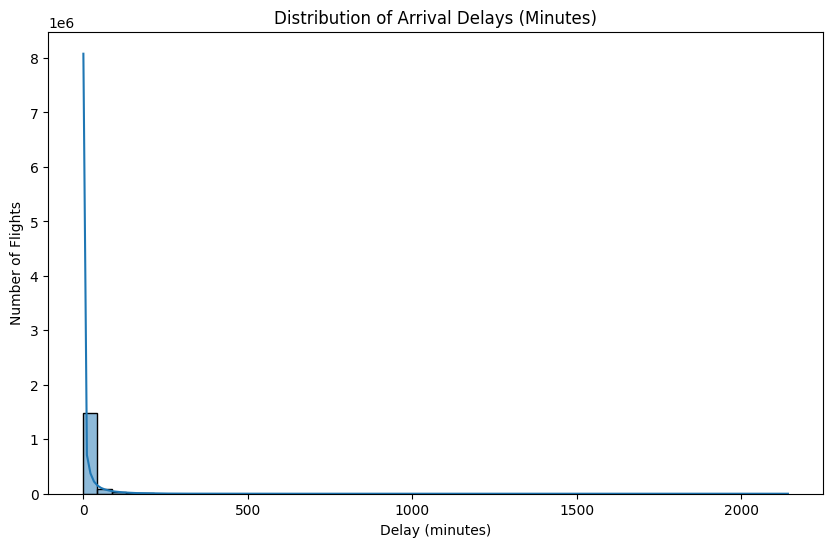

In [210]:
# Distribution of arrival delays
plt.figure(figsize=(10,6))
sns.histplot(flight_data['ArrDelayMinutes'], bins=50, kde=True)
plt.title("Distribution of Arrival Delays (Minutes)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

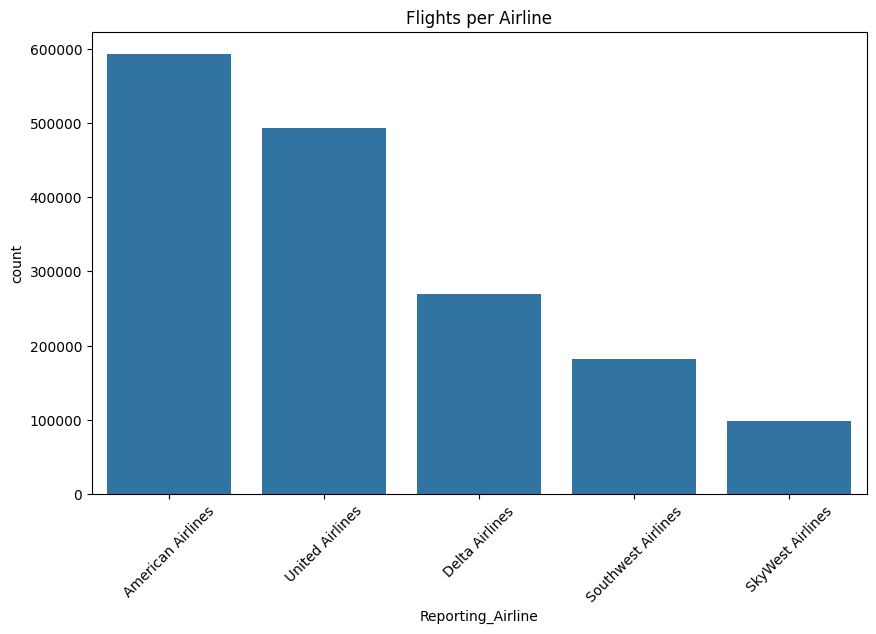

In [211]:
# Flights per airline 
plt.figure(figsize=(10,6)) 
sns.countplot(x='Reporting_Airline', data=flight_data, order=flight_data['Reporting_Airline'].value_counts().index) 
plt.title("Flights per Airline") 
plt.xticks(rotation=45) 
plt.show()

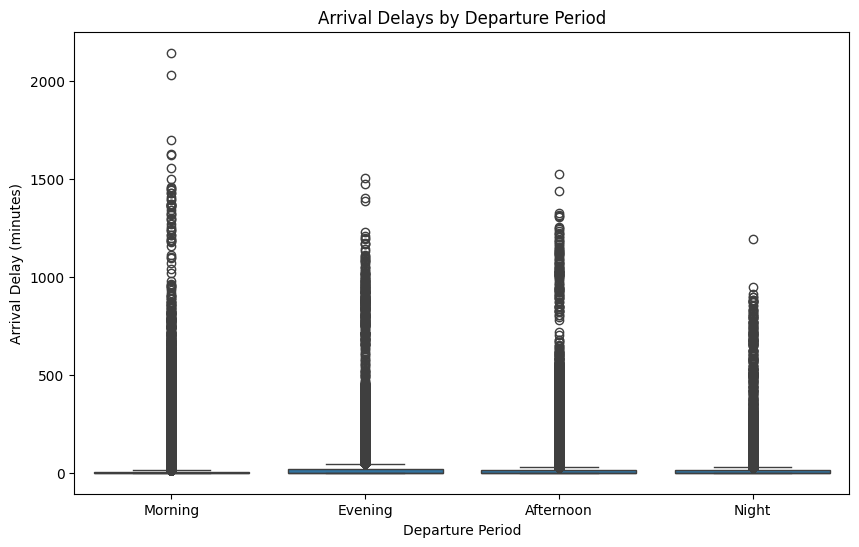

In [212]:
# Delays by departure period
plt.figure(figsize=(10,6))
sns.boxplot(x='DepPeriod', y='ArrDelayMinutes', data=flight_data)
plt.title("Arrival Delays by Departure Period")
plt.xlabel("Departure Period")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

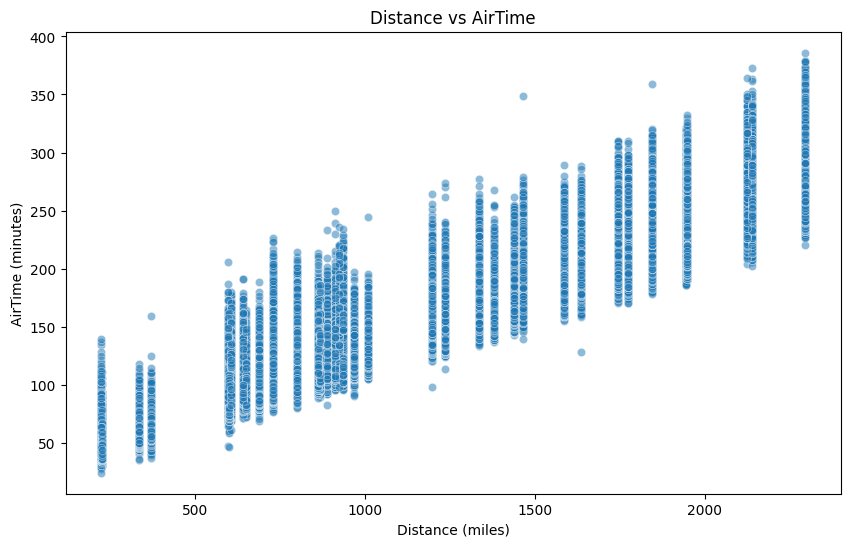

In [213]:
# Distance vs AirTime
plt.figure(figsize=(10,6))
sns.scatterplot(x='Distance', y='AirTime', data=flight_data, alpha=0.5)
plt.title("Distance vs AirTime")
plt.xlabel("Distance (miles)")
plt.ylabel("AirTime (minutes)")
plt.show()

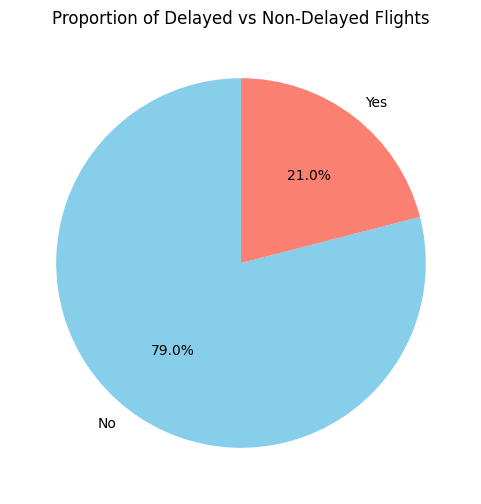

In [214]:
# Proportion of delayed vs non-delayed flights
plt.figure(figsize=(6,6))
flight_data['is_delay'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue','salmon'])
plt.title("Proportion of Delayed vs Non-Delayed Flights")
plt.ylabel("")
plt.show()

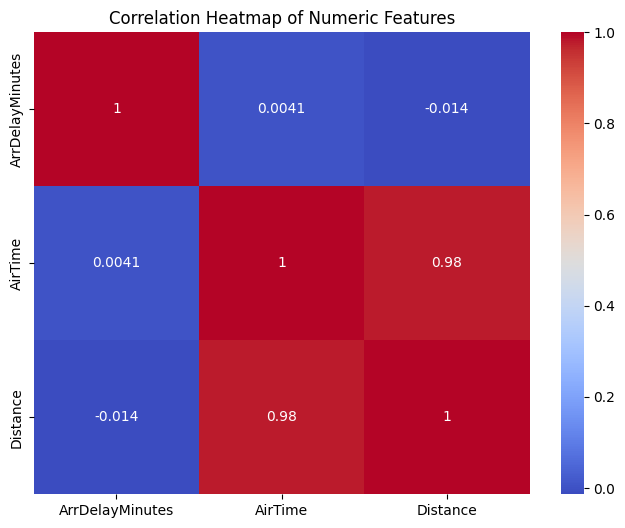

In [215]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(flight_data[['ArrDelayMinutes','AirTime','Distance']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

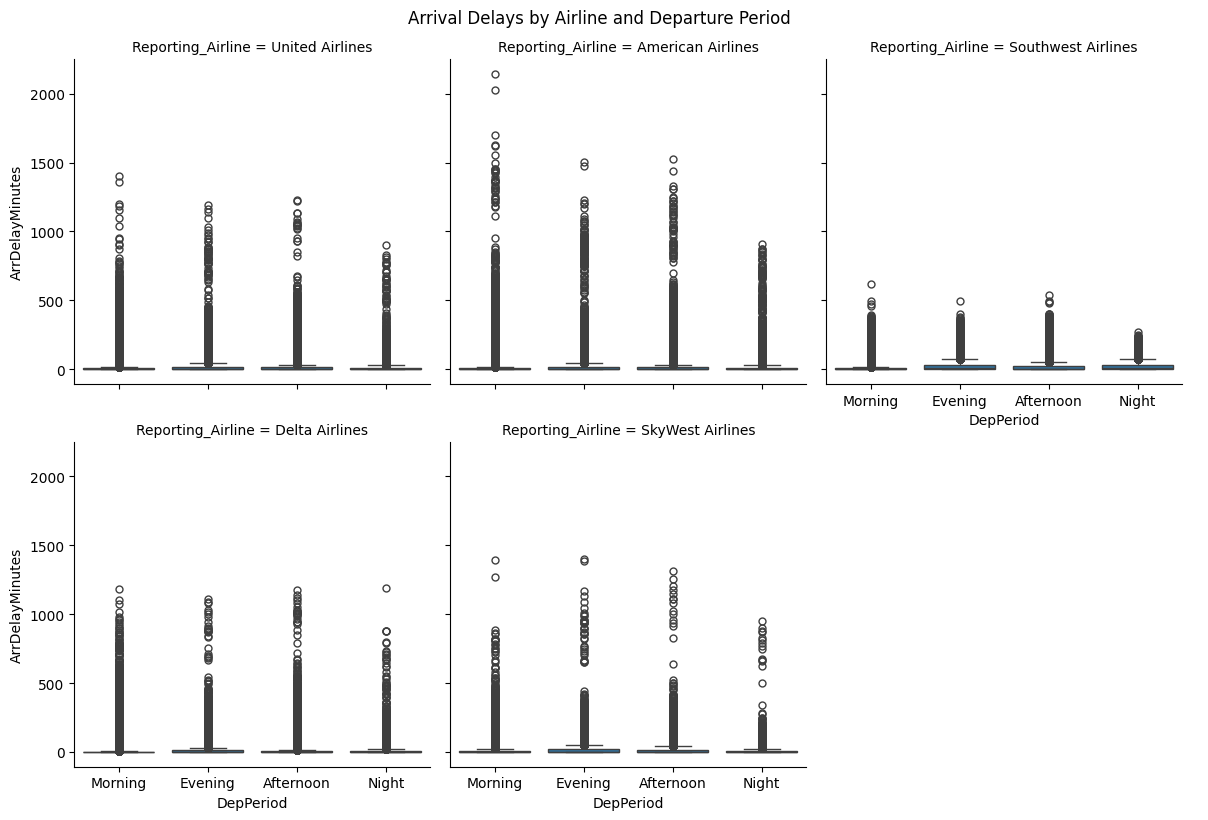

In [216]:
# Distribution of delays by airline and departure period
g = sns.catplot(x='DepPeriod', y='ArrDelayMinutes', col='Reporting_Airline',
                data=flight_data, kind='box', col_wrap=3, height=4)
g.fig.suptitle("Arrival Delays by Airline and Departure Period", y=1.02)
plt.show()

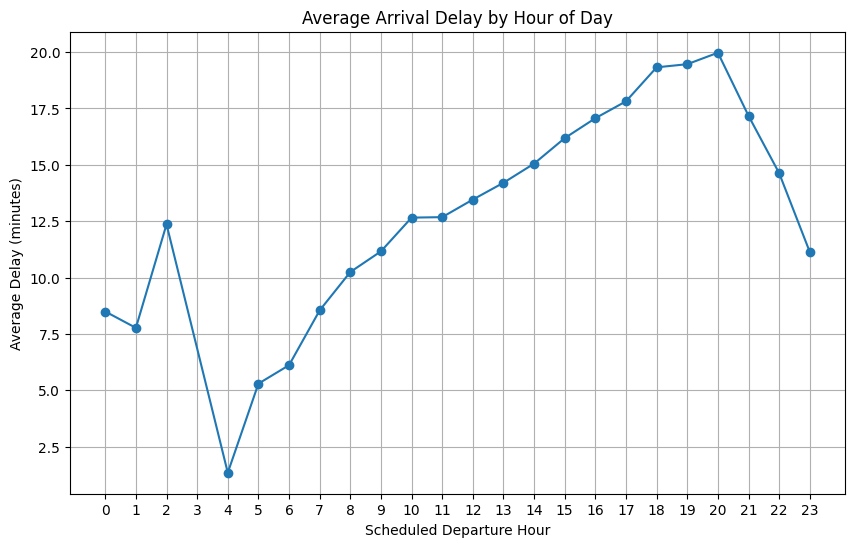

In [217]:
# Convert CRSDepTime to hour
flight_data['DepHour'] = flight_data['CRSDepTime'].str[:2].astype(int)

avg_delay_by_hour = flight_data.groupby('DepHour')['ArrDelayMinutes'].mean()

plt.figure(figsize=(10,6))
avg_delay_by_hour.plot(kind='line', marker='o')
plt.title("Average Arrival Delay by Hour of Day")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Average Delay (minutes)")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

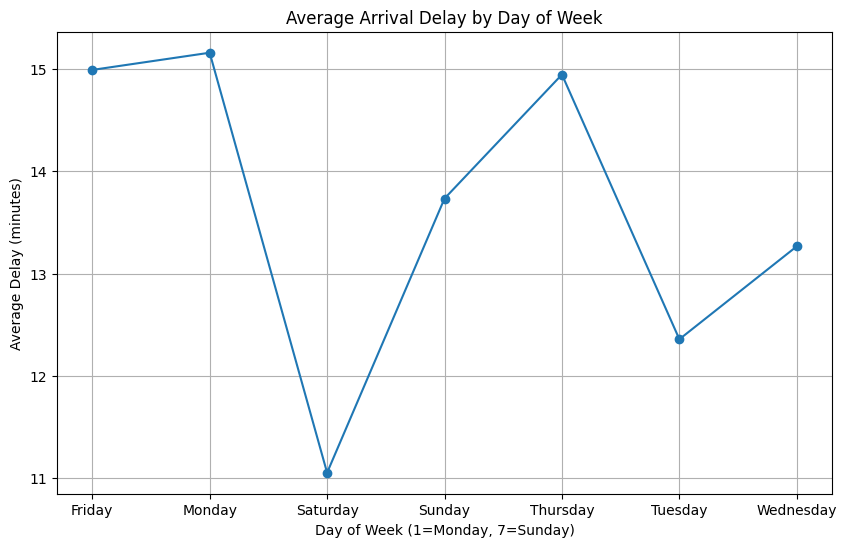

In [218]:
avg_delay_by_day = flight_data.groupby('DayOfWeek')['ArrDelayMinutes'].mean()

plt.figure(figsize=(10,6))
avg_delay_by_day.plot(kind='line', marker='o')
plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week (1=Monday, 7=Sunday)")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

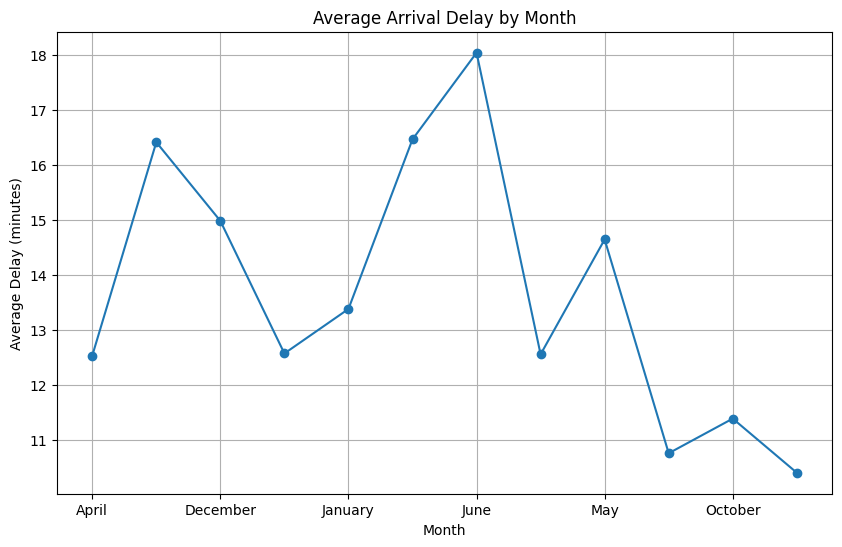

In [219]:
avg_delay_by_month = flight_data.groupby('Month')['ArrDelayMinutes'].mean()

plt.figure(figsize=(10,6))
avg_delay_by_month.plot(kind='line', marker='o')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

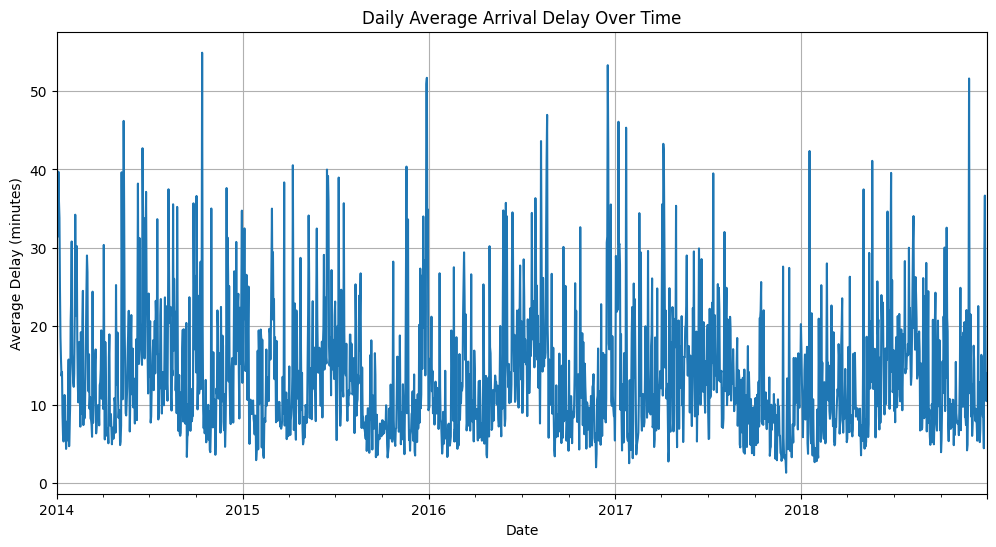

In [220]:
# Ensure FlightDate is datetime
flight_data['FlightDate'] = pd.to_datetime(flight_data['FlightDate'])

daily_delay = flight_data.groupby('FlightDate')['ArrDelayMinutes'].mean()

plt.figure(figsize=(12,6))
daily_delay.plot()
plt.title("Daily Average Arrival Delay Over Time")
plt.xlabel("Date")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

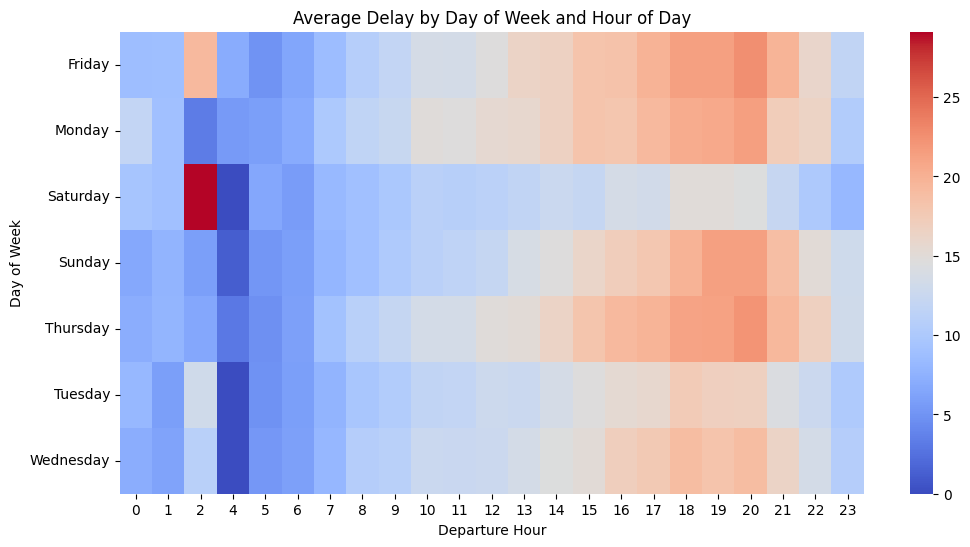

In [221]:
pivot = flight_data.pivot_table(index='DayOfWeek', columns='DepHour', values='ArrDelayMinutes', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title("Average Delay by Day of Week and Hour of Day")
plt.xlabel("Departure Hour")
plt.ylabel("Day of Week")
plt.show()

In [222]:
drop_cols = [
    'FlightDate','OriginState','DestState','DistanceGroup','ArrDelay','ArrDelayMinutes','AirTime','Cancelled','Diverted', 'CRSDepTime'
]
drop_cols

['FlightDate',
 'OriginState',
 'DestState',
 'DistanceGroup',
 'ArrDelay',
 'ArrDelayMinutes',
 'AirTime',
 'Cancelled',
 'Diverted',
 'CRSDepTime']

In [223]:
# Drop columns
dataset2 = flight_data.copy()
dataset2

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,...,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime,DepPeriod,is_delay,DepHour
0,2014,Quarter 1,January,1,Wednesday,2014-01-01,United Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,43.0,43.0,218.0,Morning,Yes,9
1,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Houston George Bush Intercontinental Airport,Texas,Dallas/Fort Worth International Airport,...,Not Cancelled,Not Diverted,224.0,1–250 miles,2.0,2.0,50.0,Evening,No,17
2,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Los Angeles International Airport,California,Chicago O’Hare International Airport,...,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,26.0,26.0,220.0,Afternoon,Yes,12
3,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Los Angeles International Airport,...,Not Cancelled,Not Diverted,1235.0,1001–1250 miles,159.0,159.0,169.0,Evening,Yes,19
4,2014,Quarter 1,January,1,Wednesday,2014-01-01,American Airlines,Dallas/Fort Worth International Airport,Texas,Charlotte Douglas International Airport,...,Not Cancelled,Not Diverted,936.0,751–1000 miles,-13.0,0.0,108.0,Morning,No,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Dallas/Fort Worth International Airport,Texas,Denver International Airport,...,Not Cancelled,Not Diverted,641.0,501–750 miles,24.0,24.0,100.0,Afternoon,Yes,14
1635586,2018,Quarter 4,December,31,Monday,2018-12-31,Delta Airlines,Phoenix Sky Harbor International Airport,Arizona,Atlanta Hartsfield–Jackson International Airport,...,Not Cancelled,Not Diverted,1587.0,1501–2000 miles,-14.0,0.0,179.0,Afternoon,No,14
1635587,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,San Francisco International Airport,...,Not Cancelled,Not Diverted,1846.0,2001–2500 miles,39.0,39.0,272.0,Evening,Yes,17
1635588,2018,Quarter 4,December,31,Monday,2018-12-31,American Airlines,Chicago O’Hare International Airport,Illinois,Los Angeles International Airport,...,Not Cancelled,Not Diverted,1744.0,1501–2000 miles,-10.0,0.0,240.0,Morning,No,7


In [224]:
dataset2 = dataset2.drop(drop_cols, axis = 1)
dataset2

,Year,Quarter,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,Distance,DepPeriod,is_delay,DepHour
0,2014,Quarter 1,January,1,Wednesday,United Airlines,Los Angeles International Airport,Chicago O’Hare International Airport,1744.0,Morning,Yes,9
1,2014,Quarter 1,January,1,Wednesday,American Airlines,Houston George Bush Intercontinental Airport,Dallas/Fort Worth International Airport,224.0,Evening,No,17
2,2014,Quarter 1,January,1,Wednesday,American Airlines,Los Angeles International Airport,Chicago O’Hare International Airport,1744.0,Afternoon,Yes,12
3,2014,Quarter 1,January,1,Wednesday,American Airlines,Dallas/Fort Worth International Airport,Los Angeles International Airport,1235.0,Evening,Yes,19
4,2014,Quarter 1,January,1,Wednesday,American Airlines,Dallas/Fort Worth International Airport,Charlotte Douglas International Airport,936.0,Morning,No,11
...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,2018,Quarter 4,December,31,Monday,American Airlines,Dallas/Fort Worth International Airport,Denver International Airport,641.0,Afternoon,Yes,14
1635586,2018,Quarter 4,December,31,Monday,Delta Airlines,Phoenix Sky Harbor International Airport,Atlanta Hartsfield–Jackson International Airport,1587.0,Afternoon,No,14
1635587,2018,Quarter 4,December,31,Monday,American Airlines,Chicago O’Hare International Airport,San Francisco International Airport,1846.0,Evening,Yes,17
1635588,2018,Quarter 4,December,31,Monday,American Airlines,Chicago O’Hare International Airport,Los Angeles International Airport,1744.0,Morning,No,7


In [225]:
dataset2.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Reporting_Airline', 'Origin', 'Dest', 'Distance', 'DepPeriod',
       'is_delay', 'DepHour'],
      dtype='object')

In [226]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635590 entries, 0 to 1635589
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Year               1635590 non-null  object 
 1   Quarter            1635590 non-null  object 
 2   Month              1635590 non-null  object 
 3   DayofMonth         1635590 non-null  object 
 4   DayOfWeek          1635590 non-null  object 
 5   Reporting_Airline  1635590 non-null  object 
 6   Origin             1635590 non-null  object 
 7   Dest               1635590 non-null  object 
 8   Distance           1635590 non-null  float64
 9   DepPeriod          1635590 non-null  object 
 10  is_delay           1635590 non-null  object 
 11  DepHour            1635590 non-null  int32  
dtypes: float64(1), int32(1), object(10)
memory usage: 143.5+ MB


In [227]:
dataset2.describe()

,Distance,DepHour
count,1.635590e+06,1.635590e+06
mean,1.011397e+03,1.287102e+01
std,5.381231e+02,4.974134e+00
min,2.240000e+02,0.000000e+00
25%,6.060000e+02,9.000000e+00
50%,8.680000e+02,1.300000e+01
75%,1.440000e+03,1.700000e+01
max,2.296000e+03,2.300000e+01


In [228]:
# Standardize
scaler = MinMaxScaler()
scaler

MinMaxScaler()

In [229]:
# Encoding
le = LabelEncoder()
le

LabelEncoder()

In [230]:
numerical_columns = ['Distance','DepHour']
numerical_columns

['Distance', 'DepHour']

In [231]:
dataset2[numerical_columns] = scaler.fit_transform(dataset2[numerical_columns])
dataset2[numerical_columns]

,Distance,DepHour
0,0.733591,0.391304
1,0.000000,0.739130
2,0.733591,0.521739
3,0.487934,0.826087
4,0.343629,0.478261
...,...,...
1635585,0.201255,0.608696
1635586,0.657819,0.608696
1635587,0.782819,0.739130
1635588,0.733591,0.304348


In [232]:
cat_columns = [
    'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
    'Reporting_Airline', 'Origin', 'Dest', 'DepPeriod'
]
cat_columns

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'Reporting_Airline',
 'Origin',
 'Dest',
 'DepPeriod']

In [233]:
label_encoders = {}

for col in cat_columns: 
    le = LabelEncoder()
    dataset2[col] = le.fit_transform(dataset2[col].astype(str))
    label_encoders[col] = le

In [234]:
label_encoders['Year'].classes_

array(['2014', '2015', '2016', '2017', '2018'], dtype=object)

In [235]:
label_encoders['Quarter'].classes_

array(['Quarter 1', 'Quarter 2', 'Quarter 3', 'Quarter 4'], dtype=object)

In [236]:
label_encoders['Month'].classes_

array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object)

In [237]:
label_encoders['DayofMonth'].classes_

array(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '3', '30', '31', '4', '5', '6', '7', '8', '9'], dtype=object)

In [238]:
label_encoders['DayOfWeek'].classes_

array(['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday'], dtype=object)

In [239]:
label_encoders['Reporting_Airline'].classes_

array(['American Airlines', 'Delta Airlines', 'SkyWest Airlines',
       'Southwest Airlines', 'United Airlines'], dtype=object)

In [240]:
label_encoders['Origin'].classes_

array(['Atlanta Hartsfield–Jackson International Airport',
       'Charlotte Douglas International Airport',
       'Chicago O’Hare International Airport',
       'Dallas/Fort Worth International Airport',
       'Denver International Airport',
       'Houston George Bush Intercontinental Airport',
       'Los Angeles International Airport',
       'Phoenix Sky Harbor International Airport',
       'San Francisco International Airport'], dtype=object)

In [241]:
label_encoders['Dest'].classes_

array(['Atlanta Hartsfield–Jackson International Airport',
       'Charlotte Douglas International Airport',
       'Chicago O’Hare International Airport',
       'Dallas/Fort Worth International Airport',
       'Denver International Airport',
       'Houston George Bush Intercontinental Airport',
       'Los Angeles International Airport',
       'Phoenix Sky Harbor International Airport',
       'San Francisco International Airport'], dtype=object)

In [242]:
label_encoders['DepPeriod'].classes_

array(['Afternoon', 'Evening', 'Morning', 'Night'], dtype=object)

In [243]:
label_encoders

{'Year': LabelEncoder(),
 'Quarter': LabelEncoder(),
 'Month': LabelEncoder(),
 'DayofMonth': LabelEncoder(),
 'DayOfWeek': LabelEncoder(),
 'Reporting_Airline': LabelEncoder(),
 'Origin': LabelEncoder(),
 'Dest': LabelEncoder(),
 'DepPeriod': LabelEncoder()}

In [244]:
dataset2[col]

0          2
1          1
2          0
3          1
4          2
          ..
1635585    0
1635586    0
1635587    1
1635588    2
1635589    0
Name: DepPeriod, Length: 1635590, dtype: int32

In [245]:
dataset2

,Year,Quarter,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,Distance,DepPeriod,is_delay,DepHour
0,0,0,4,0,6,4,6,2,0.733591,2,Yes,0.391304
1,0,0,4,0,6,0,5,3,0.000000,1,No,0.739130
2,0,0,4,0,6,0,6,2,0.733591,0,Yes,0.521739
3,0,0,4,0,6,0,3,6,0.487934,1,Yes,0.826087
4,0,0,4,0,6,0,3,1,0.343629,2,No,0.478261
...,...,...,...,...,...,...,...,...,...,...,...,...
1635585,4,3,2,24,1,0,3,4,0.201255,0,Yes,0.608696
1635586,4,3,2,24,1,1,7,0,0.657819,0,No,0.608696
1635587,4,3,2,24,1,0,2,8,0.782819,1,Yes,0.739130
1635588,4,3,2,24,1,0,2,6,0.733591,2,No,0.304348


In [246]:
# Feature Variable
X = dataset2.drop(['is_delay'], axis = 1)
X

,Year,Quarter,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,Distance,DepPeriod,DepHour
0,0,0,4,0,6,4,6,2,0.733591,2,0.391304
1,0,0,4,0,6,0,5,3,0.000000,1,0.739130
2,0,0,4,0,6,0,6,2,0.733591,0,0.521739
3,0,0,4,0,6,0,3,6,0.487934,1,0.826087
4,0,0,4,0,6,0,3,1,0.343629,2,0.478261
...,...,...,...,...,...,...,...,...,...,...,...
1635585,4,3,2,24,1,0,3,4,0.201255,0,0.608696
1635586,4,3,2,24,1,1,7,0,0.657819,0,0.608696
1635587,4,3,2,24,1,0,2,8,0.782819,1,0.739130
1635588,4,3,2,24,1,0,2,6,0.733591,2,0.304348


In [247]:
y = dataset2['is_delay']
y

0          Yes
1           No
2          Yes
3          Yes
4           No
          ... 
1635585    Yes
1635586     No
1635587    Yes
1635588     No
1635589    Yes
Name: is_delay, Length: 1635590, dtype: object

In [248]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1308472, 11)
(327118, 11)
(1308472,)
(327118,)


In [249]:
# Logistic Regression
lr =  LogisticRegression(max_iter=500, solver='liblinear', C=1.0)
lr

LogisticRegression(max_iter=500, solver='liblinear')

In [250]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=500, solver='liblinear')

In [251]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [252]:
cr_lr = classification_report(y_test, y_pred_lr)
print("Classification Report:\n",cr_lr)

Classification Report:
               precision    recall  f1-score   support

          No       0.79      1.00      0.88    258201
         Yes       0.00      0.00      0.00     68917

    accuracy                           0.79    327118
   macro avg       0.39      0.50      0.44    327118
weighted avg       0.62      0.79      0.70    327118



In [253]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n",cm_lr)

Confusion Matrix:
 [[258201      0]
 [ 68917      0]]


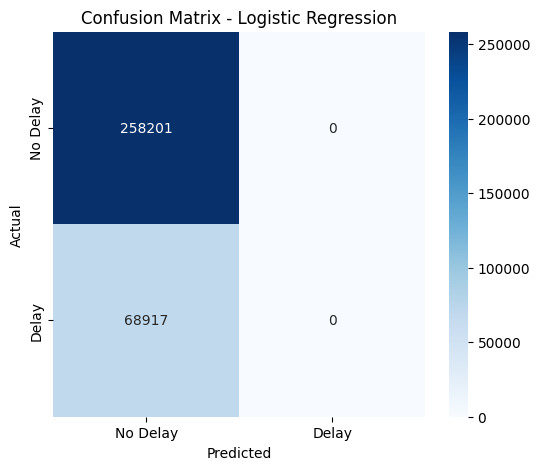

In [254]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Delay', 'Delay'], 
            yticklabels=['No Delay', 'Delay']) 
plt.title("Confusion Matrix - Logistic Regression") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

In [255]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2),"%")

Logistic Regression Accuracy: 78.93 %


KNN Classifier

In [256]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn

KNeighborsClassifier()

In [257]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [258]:
y_pred_knn = knn.predict(X_test)
y_pred_knn

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [259]:
cr_knn = classification_report(y_test, y_pred_knn)
print("Classification Report:\n",cr_knn)

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.93      0.88    258201
         Yes       0.52      0.29      0.37     68917

    accuracy                           0.79    327118
   macro avg       0.67      0.61      0.62    327118
weighted avg       0.76      0.79      0.77    327118



In [260]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n",cm_knn)

Confusion Matrix:
 [[239603  18598]
 [ 48862  20055]]


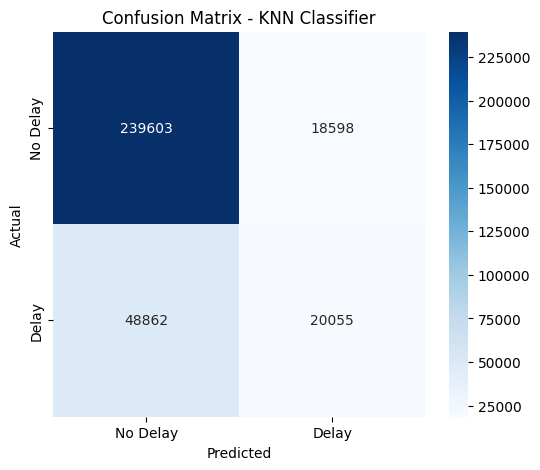

In [261]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Delay', 'Delay'], 
            yticklabels=['No Delay', 'Delay']) 
plt.title("Confusion Matrix - KNN Classifier") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

In [262]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Classifier Accuracy:", round(accuracy_knn * 100, 2),"%")

KNN Classifier Accuracy: 79.38 %


Decision Tree Classifier

In [263]:
dtc = DecisionTreeClassifier(max_depth=10, criterion='gini', random_state=42)
dtc

DecisionTreeClassifier(max_depth=10, random_state=42)

In [264]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [265]:
y_pred_dtc = dtc.predict(X_test)
y_pred_dtc

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [266]:
cr_dtc = classification_report(y_test, y_pred_dtc)
print("Classification Report:\n",cr_knn)

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.93      0.88    258201
         Yes       0.52      0.29      0.37     68917

    accuracy                           0.79    327118
   macro avg       0.67      0.61      0.62    327118
weighted avg       0.76      0.79      0.77    327118



In [267]:
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
print("Confusion Matrix:\n",cm_knn)

Confusion Matrix:
 [[239603  18598]
 [ 48862  20055]]


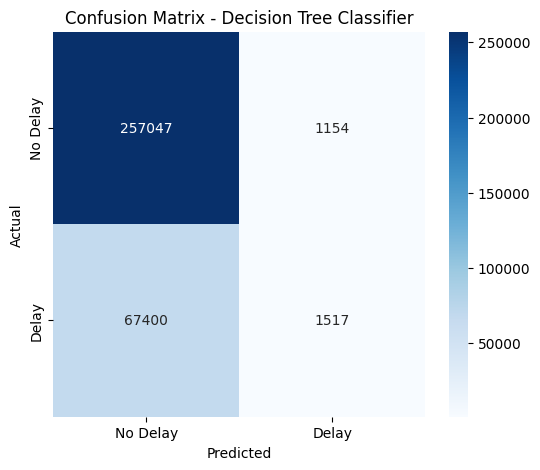

In [268]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Delay', 'Delay'], 
            yticklabels=['No Delay', 'Delay']) 
plt.title("Confusion Matrix - Decision Tree Classifier") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

In [269]:
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print("Decision Tree Classifier Accuracy:", round(accuracy_dtc * 100, 2),"%")

Decision Tree Classifier Accuracy: 79.04 %


Random Forest Classifier

In [270]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rfc

RandomForestClassifier(max_depth=15, random_state=42)

In [271]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, random_state=42)

In [272]:
y_pred_rfc = rfc.predict(X_test)
y_pred_rfc

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [273]:
cr_rfc = classification_report(y_test, y_pred_rfc)
print("Classification Report:\n",cr_rfc)

Classification Report:
               precision    recall  f1-score   support

          No       0.79      1.00      0.88    258201
         Yes       0.72      0.03      0.05     68917

    accuracy                           0.79    327118
   macro avg       0.76      0.51      0.47    327118
weighted avg       0.78      0.79      0.71    327118



In [274]:
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
print("Confusion Matrix:\n",cm_rfc)

Confusion Matrix:
 [[257476    725]
 [ 67006   1911]]


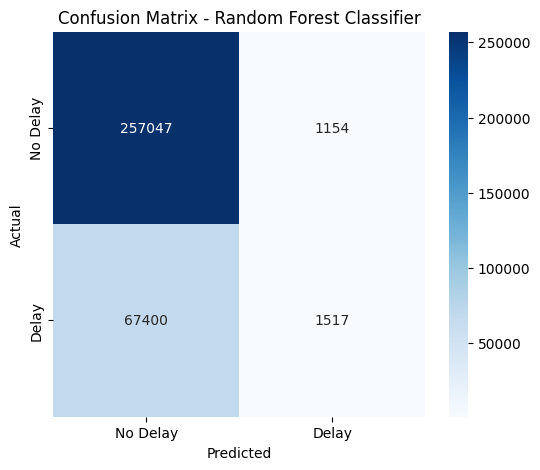

In [275]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Delay', 'Delay'], 
            yticklabels=['No Delay', 'Delay']) 
plt.title("Confusion Matrix - Random Forest Classifier") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

In [276]:
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print("Random Forest Classifier Accuracy:", round(accuracy_rfc * 100, 2),"%")

Random Forest Classifier Accuracy: 79.29 %


Comparison of Accuracies

In [277]:
model_accuracies = {
    "Logistic Regression" : round(accuracy_lr*100,2),
    "KNN Classifier" : round(accuracy_knn*100,2),
    "Decision Tree Classifier" : round(accuracy_dtc*100,2),
    "Random Forest Classifier" : round(accuracy_rfc*100,2)
}
model_accuracies

{'Logistic Regression': 78.93,
 'KNN Classifier': 79.38,
 'Decision Tree Classifier': 79.04,
 'Random Forest Classifier': 79.29}

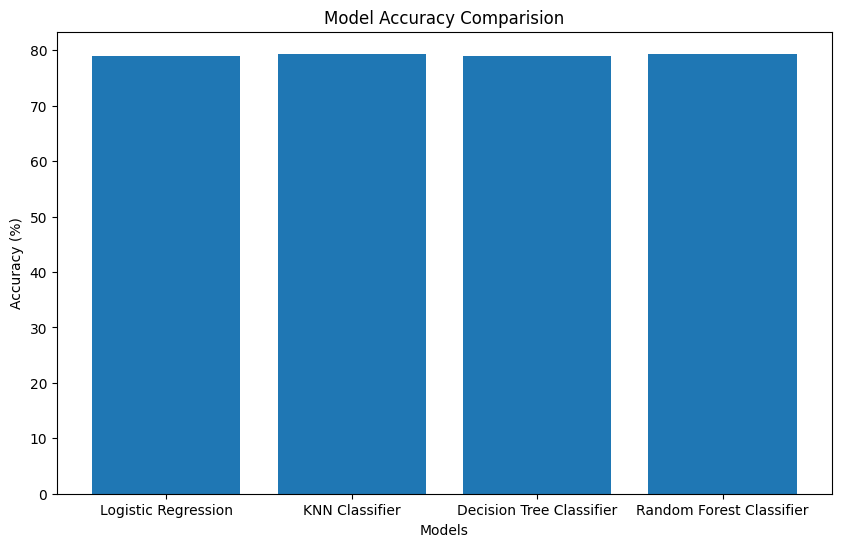

In [278]:
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize = (10, 6))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparision")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()

Serialization

In [279]:
# Save Scaler
joblib.dump(scaler,"models/scaler.pkl")
joblib.dump(label_encoders,"models/label_encoder.pkl")

['models/label_encoder.pkl']

In [280]:
# Save Models
joblib.dump(lr,"models/lr.pkl")
joblib.dump(knn,"models/knn.pkl")
joblib.dump(dtc,"models/dtc.pkl")
joblib.dump(rfc,"models/rfc.pkl")

['models/rfc.pkl']

In [281]:
# Save Accuracies
joblib.dump(model_accuracies, "models/model_accuracy.pkl")

['models/model_accuracy.pkl']